<a href="https://colab.research.google.com/github/LorenzoMedina-lab/CodePro_California_housing/blob/main/Analisis_energia_datacenter_defensa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis energético para la preselección de un datacenter en Brasil

## Objetivo

El objetivo es analizar el consumo eléctrico de Brasil e identificar **estados candidatos** donde tendría sentido profundizar un estudio para instalar un centro de datos.


### Alcance

El dataset contiene información de **consumo**, pero no incluye precio de electricidad, capacidad disponible de red, interrupciones ni conectividad. Por eso, el resultado final es una **preselección energética**, no una decisión definitiva sobre dónde construir el datacenter.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Carga y exploración inicial

Primero revisamos la estructura del dataset antes de realizar cualquier transformación. El objetivo es conocer dimensiones, columnas, tipos de datos y valores faltantes.

In [ ]:
# Librerías utilizadas para manipulación y visualización de datos.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Estilo visual uniforme.
sns.set_theme(style='whitegrid')

# Ruta del dataset en Drive.
ruta_archivo = '/content/drive/MyDrive/CodePro5.0/Dados brutos.xlsx'

# Cargamos el archivo original.
df_original = pd.read_excel(ruta_archivo)

print('Dimensiones del dataset:', df_original.shape)
print()
print('Valores faltantes por columna:')
print(df_original.isnull().sum())

print()
print('Primeros registros:')
display(df_original.head(3))

Dimensiones del dataset: (285499, 14)

Valores faltantes por columna:
Data                       0
TipoConsumidor             0
Sistema                    0
UF                         0
Setor Econômico - N1       0
Setor Econômico - N2       0
Setor Econômico - N3       0
Tipo Tensão - N1           0
Tipo Tensão - N2           0
Tipo Tensão - N3           0
Faixa de Consumo N1        0
Faixa de Consumo N2        0
Consumidores            3988
Consumo                 9700
dtype: int64

Primeros registros:


,Data,TipoConsumidor,Sistema,UF,Setor Econômico - N1,Setor Econômico - N2,Setor Econômico - N3,Tipo Tensão - N1,Tipo Tensão - N2,Tipo Tensão - N3,Faixa de Consumo N1,Faixa de Consumo N2,Consumidores,Consumo
0,20140101,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
1,20140201,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
2,20140301,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0


In [ ]:
# info() muestra nombres de columnas, tipos de datos y cantidad de valores no nulos.
df_original.info()

# describe() resume estadísticamente las variables numéricas.
display(df_original.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285499 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Data                  285499 non-null  int64  
 1   TipoConsumidor        285499 non-null  object 
 2   Sistema               285499 non-null  object 
 3   UF                    285499 non-null  object 
 4   Setor Econômico - N1  285499 non-null  object 
 5   Setor Econômico - N2  285499 non-null  object 
 6   Setor Econômico - N3  285499 non-null  object 
 7   Tipo Tensão - N1      285499 non-null  object 
 8   Tipo Tensão - N2      285499 non-null  object 
 9   Tipo Tensão - N3      285499 non-null  object 
 10  Faixa de Consumo N1   285499 non-null  object 
 11  Faixa de Consumo N2   285499 non-null  object 
 12  Consumidores          281511 non-null  float64
 13  Consumo               275799 non-null  float64
dtypes: float64(2), int64(1), object(11)
memory usage: 30

,Data,Consumidores,Consumo
count,2.854990e+05,2.815110e+05,2.757990e+05
mean,2.018754e+07,3.572126e+04,1.758421e+04
std,2.862986e+04,2.078181e+05,7.510192e+04
min,2.014010e+07,-5.108800e+04,-2.093080e+05
25%,2.016090e+07,9.000000e+00,1.090000e+02
50%,2.019040e+07,1.320000e+02,1.470000e+03
75%,2.021090e+07,3.222000e+03,9.614000e+03
max,2.023120e+07,6.652168e+06,1.850736e+06


### Variables relevantes

Para el objetivo del datacenter nos interesan especialmente:

- `Data`: fecha del registro.
- `UF`: estado de Brasil.
- `Sistema`: sistema eléctrico.
- `TipoConsumidor`: mercado `Cativo` o `Livre`.
- `Setor Econômico - N1`: sector económico principal.
- `Consumidores`: cantidad de consumidores.
- `Consumo`: consumo energético registrado.

El análisis no utiliza todas las columnas del dataset. Seleccionamos las que aportan directamente a la pregunta planteada.

## 2. Preparación, filtrado y limpieza

Para acercar el análisis al tipo de demanda de un datacenter utilizamos un segmento específico:

1. excluimos `Sistemas Isolados`;
2. conservamos `TipoConsumidor == 'Livre'`;
3. conservamos `Setor Econômico - N1 == 'Industrial'`.

El mercado libre y el sector industrial se utilizan como **aproximación analítica a grandes consumidores eléctricos**. Esto no significa que un datacenter sea una industria ni que pertenecer al mercado libre garantice energía barata.

In [ ]:
# Trabajamos sobre una copia para conservar intacto el DataFrame original.
df = df_original.copy()

# Convertimos la fecha numérica AAAAMMDD a datetime.
df['Data'] = pd.to_datetime(
    df['Data'].astype(str),
    format='%Y%m%d'
)

# Creamos año y mes para realizar agrupaciones temporales.
df['ano'] = df['Data'].dt.year
df['mes'] = df['Data'].dt.month

# Aplicamos los filtros relacionados con el objetivo del datacenter.
df_filtrado = df[
    (df['Sistema'] != 'Sistemas Isolados') &
    (df['TipoConsumidor'] == 'Livre') &
    (df['Setor Econômico - N1'] == 'Industrial')
].copy()

print('Registros originales:', len(df))
print('Registros después de los filtros:', len(df_filtrado))

# Para los cálculos principales necesitamos Consumo y Consumidores disponibles.
# Eliminamos nulos y valores negativos únicamente dentro del segmento de análisis.
df_filtrado = df_filtrado.dropna(
    subset=['Consumo', 'Consumidores']
).copy()

df_filtrado = df_filtrado[
    (df_filtrado['Consumo'] >= 0) &
    (df_filtrado['Consumidores'] >= 0)
].copy()

print('Registros después de la limpieza:', len(df_filtrado))
print('Período:', df_filtrado['Data'].min(), 'a', df_filtrado['Data'].max())

Registros originales: 285499
Registros después de los filtros: 10996
Registros después de la limpieza: 10610
Período: 2014-01-01 00:00:00 a 2023-12-01 00:00:00


### Agregación mensual y cobertura temporal

El dataset contiene múltiples filas para un mismo estado y mes. Para comparar estados de manera consistente, agregamos `Consumo` y `Consumidores` por `UF`, año y mes.

Además, conservamos únicamente estados con al menos **115 de los 120 meses posibles**, evitando comparar series con historiales demasiado incompletos.

In [ ]:
# Una observación mensual por estado dentro del segmento seleccionado.
df_mensual_uf = (
    df_filtrado
    .groupby(['UF', 'ano', 'mes'], as_index=False)[['Consumo', 'Consumidores']]
    .sum()
)

# Fecha mensual necesaria para las series temporales.
df_mensual_uf['Fecha'] = pd.to_datetime(
    dict(
        year=df_mensual_uf['ano'],
        month=df_mensual_uf['mes'],
        day=1
    )
)

# Contamos meses disponibles por estado.
conteo_meses = df_mensual_uf['UF'].value_counts()
ufs_validos = conteo_meses[conteo_meses >= 115].index

# Este será el DataFrame principal del análisis comparativo.
df_analisis = df_mensual_uf[
    df_mensual_uf['UF'].isin(ufs_validos)
].copy()

print('Estados con al menos 115 meses:', len(ufs_validos))
print('Registros mensuales utilizados:', len(df_analisis))

Estados con al menos 115 meses: 22
Registros mensuales utilizados: 2639


# 3. Análisis exploratorio

Esta sección cubre los requisitos de **distribución individual, distribución segmentada, correlación y pairplot**.

## 3.1 Distribución individual del consumo


**Pregunta:** ¿Cómo se distribuyen los niveles de consumo energético registrados?

Utilizamos un histograma para observar dónde se concentra la mayor cantidad de registros y detectar si existen valores extremos o una distribución asimétrica.

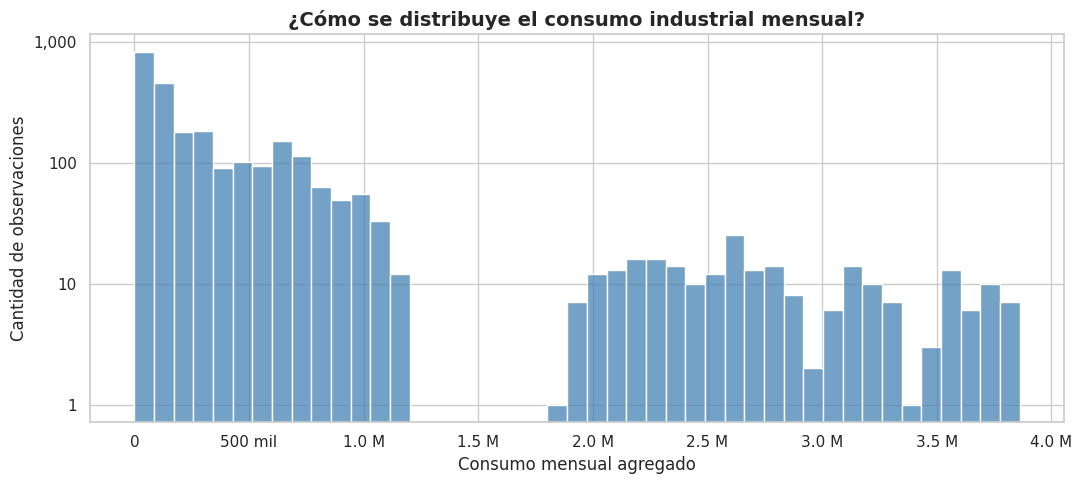

In [ ]:
# Función para mostrar valores grandes de forma más amigable.
def formato_compacto(x, pos):
    if abs(x) >= 1_000_000:
        return f'{x / 1_000_000:.1f} M'
    if abs(x) >= 1_000:
        return f'{x / 1_000:.0f} mil'
    return f'{x:.0f}'

plt.figure(figsize=(11, 5))

ax = sns.histplot(
    data=df_analisis,
    x='Consumo',
    bins=45,
    color='steelblue'
)

# La escala logarítmica afecta a la frecuencia, no a los valores de consumo.
ax.set_yscale('log')
ax.xaxis.set_major_formatter(FuncFormatter(formato_compacto))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y:,.0f}'))

plt.title(
    '¿Cómo se distribuye el consumo industrial mensual?',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Consumo mensual agregado')
plt.ylabel('Cantidad de observaciones')
plt.tight_layout()
plt.show()

**Interpretación:** La mayor parte de las observaciones se concentra en niveles relativamente bajos de consumo, mientras que una cantidad mucho menor alcanza valores muy elevados.

**Conclusión:** El consumo presenta una distribución fuertemente asimétrica. Esto indica que el dataset combina muchos registros de consumo moderado con un grupo reducido de observaciones de gran magnitud.

## 3.2 Distribución segmentada por estado

**Pregunta:** ¿cómo cambia la distribución del consumo entre los estados de mayor nivel mensual?

Usamos un boxplot porque permite comparar mediana, dispersión y valores extremos. Para mantener el gráfico legible mostramos únicamente las **cinco UF con mayor mediana mensual de consumo**.

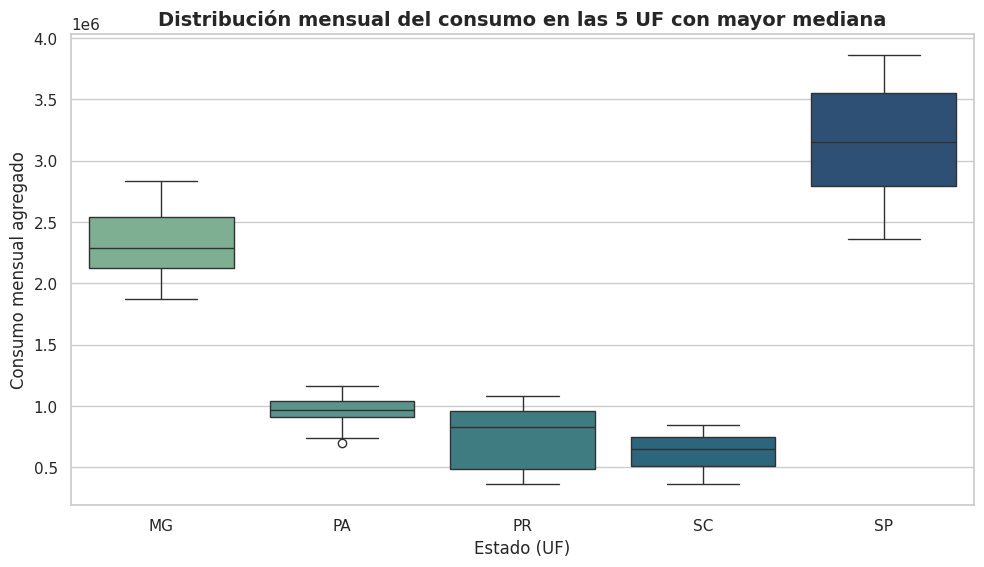

In [ ]:
# Seleccionamos las cinco UF con mayor mediana mensual de consumo.
top5_mediana = (
    df_analisis
    .groupby('UF')['Consumo']
    .median()
    .nlargest(5)
    .index
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_analisis[df_analisis['UF'].isin(top5_mediana)],
    x='UF',
    y='Consumo',
    hue='UF',
    palette='crest',
    legend=False
)

plt.title(
    'Distribución mensual del consumo en las 5 UF con mayor mediana',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Estado (UF)')
plt.ylabel('Consumo mensual agregado')
plt.tight_layout()
plt.show()

**Interpretación:** Las distribuciones presentan diferencias importantes entre estados. Algunas UF muestran valores centrales más elevados y una mayor dispersión del consumo.

**Conclusión:** El comportamiento energético no es uniforme entre los estados, lo que justifica continuar el análisis territorial antes de seleccionar posibles ubicaciones para un datacenter.

## 3.3 Correlación y pairplot

**Pregunta:** ¿existe relación entre la cantidad de consumidores industriales y el consumo registrado?

La correlación resume la relación lineal y el pairplot permite observar visualmente tanto las distribuciones como la relación entre ambas variables.

**Importante:** correlación no implica causalidad.

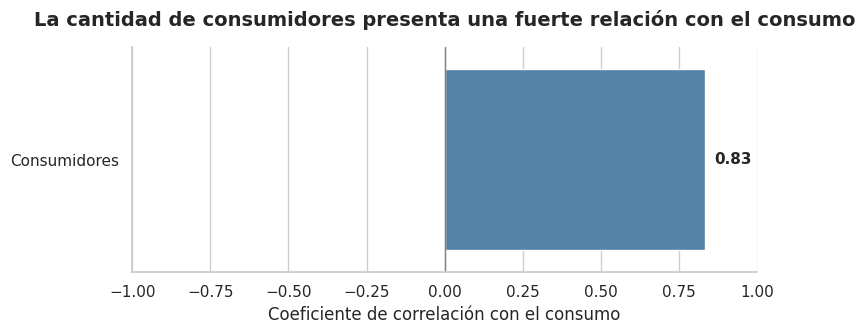

In [ ]:
# Calculamos la correlación lineal entre ambas variables.
correlacion = (
    df_analisis['Consumidores']
    .corr(df_analisis['Consumo'])
)

plt.figure(figsize=(8, 3.5))

ax = sns.barplot(
    x=[correlacion],
    y=['Consumidores'],
    color='steelblue'
)

# Línea central para identificar correlaciones
# positivas y negativas.
plt.axvline(
    0,
    color='gray',
    linewidth=1
)

plt.title(
    'La cantidad de consumidores presenta una fuerte relación con el consumo',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel('Coeficiente de correlación con el consumo')
plt.ylabel('')

# La correlación siempre se encuentra entre -1 y 1.
plt.xlim(-1, 1)

# Mostramos el valor directamente sobre la barra.
ax.text(
    correlacion + 0.03,
    0,
    f'{correlacion:.2f}',
    va='center',
    ha='left',
    fontweight='bold',
    fontsize=11
)

sns.despine()
plt.tight_layout()
plt.show()

**Interpretación:** La correlación entre `Consumidores` y `Consumo` es aproximadamente **0,83**, lo que representa una asociación lineal positiva fuerte.

**Conclusión:** En general, los registros con una mayor cantidad de consumidores tienden a presentar mayores niveles de consumo.

**Importante:** correlación no implica causalidad. Este resultado indica asociación entre las variables, pero no demuestra que una sea la causa directa de la otra.

## Comparación conjunta de las variables numéricas

El pairplot permite observar simultáneamente la distribución individual de `Consumidores` y `Consumo`, además de la relación entre ambas variables.

Se utiliza como complemento del coeficiente de correlación, ya que permite observar visualmente dispersión y valores extremos.

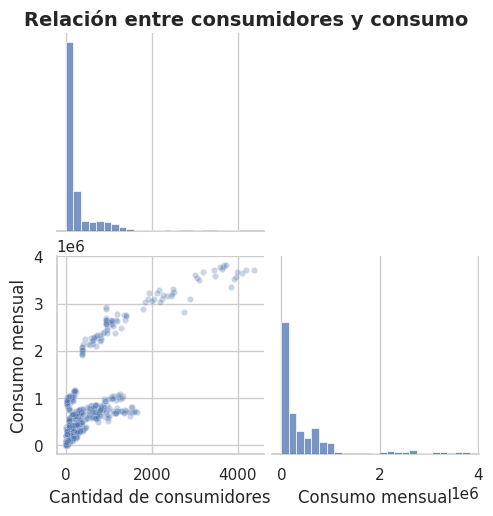

In [ ]:
# Usamos una muestra reproducible para que el pairplot sea liviano y legible.
muestra_pair = (
    df_analisis[['Consumidores', 'Consumo']]
    .sample(
        n=min(1000, len(df_analisis)),
        random_state=42
    )
    .rename(columns={
        'Consumidores': 'Cantidad de consumidores',
        'Consumo': 'Consumo mensual'
    })
)

sns.pairplot(
    muestra_pair,
    corner=True,
    diag_kind='hist',
    plot_kws={'alpha': 0.30, 's': 20},
    diag_kws={'bins': 25}
)

plt.suptitle(
    'Relación entre consumidores y consumo',
    y=1.02,
    fontsize=14,
    fontweight='bold'
)
plt.show()

**Interpretación:** La nube de puntos confirma visualmente una relación positiva entre cantidad de consumidores y consumo, aunque existe dispersión y algunos valores extremos.

**Conclusión:** El pairplot refuerza el resultado obtenido mediante la correlación: las dos variables están fuertemente asociadas, pero la relación no es perfectamente proporcional.

# 4. Análisis territorial: ¿dónde se concentra el consumo?

Para aproximarnos a la ubicación del datacenter, sumamos el consumo del período por estado. Esto identifica dónde existe una **gran escala histórica de demanda industrial** dentro del segmento analizado.

Agrupamos los registros por UF y sumamos el consumo para comparar la magnitud acumulada entre estados.

Un consumo alto no demuestra que exista capacidad eléctrica disponible para un nuevo datacenter; solamente muestra la magnitud de demanda observada.

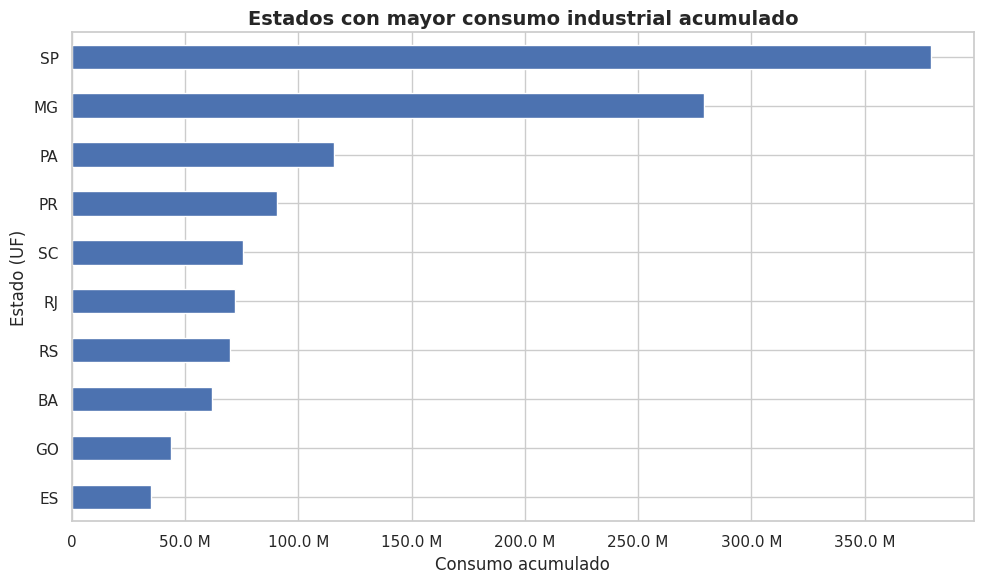

In [ ]:
# Consumo acumulado por UF durante el período analizado.
consumo_total_uf = (
    df_analisis
    .groupby('UF')['Consumo']
    .sum()
    .sort_values(ascending=False)
)

# Mostramos los 10 primeros estados para mantener el gráfico legible.
top10_consumo = consumo_total_uf.head(10).sort_values()

plt.figure(figsize=(10, 6))

ax = top10_consumo.plot(kind='barh')
ax.xaxis.set_major_formatter(FuncFormatter(formato_compacto))

plt.title(
    'Estados con mayor consumo industrial acumulado',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Consumo acumulado')
plt.ylabel('Estado (UF)')
plt.tight_layout()
plt.show()

**Interpretación:** Algunos estados concentran una proporción considerablemente mayor del consumo industrial del mercado libre.

**Conclusión:** Las UF con mayor consumo representan los primeros candidatos territoriales para continuar el análisis, ya que muestran una presencia histórica relevante de grandes cargas energéticas.

Sin embargo, un alto consumo por sí solo no garantiza que un estado sea adecuado para instalar un datacenter.

# 5. Evolución temporal y el cambio alrededor de 2020

La caída observada alrededor de 2020 en el dataset general merece una comprobación más cuidadosa.

Comparamos dos series:

- **Brasil completo:** todos los registros del dataset.
- **Industrial Livre:** el segmento utilizado para el análisis del datacenter.

Como ambas series tienen escalas muy diferentes, las convertimos a un índice donde **2014 = 100**. Así comparamos su evolución relativa y no sus magnitudes absolutas.

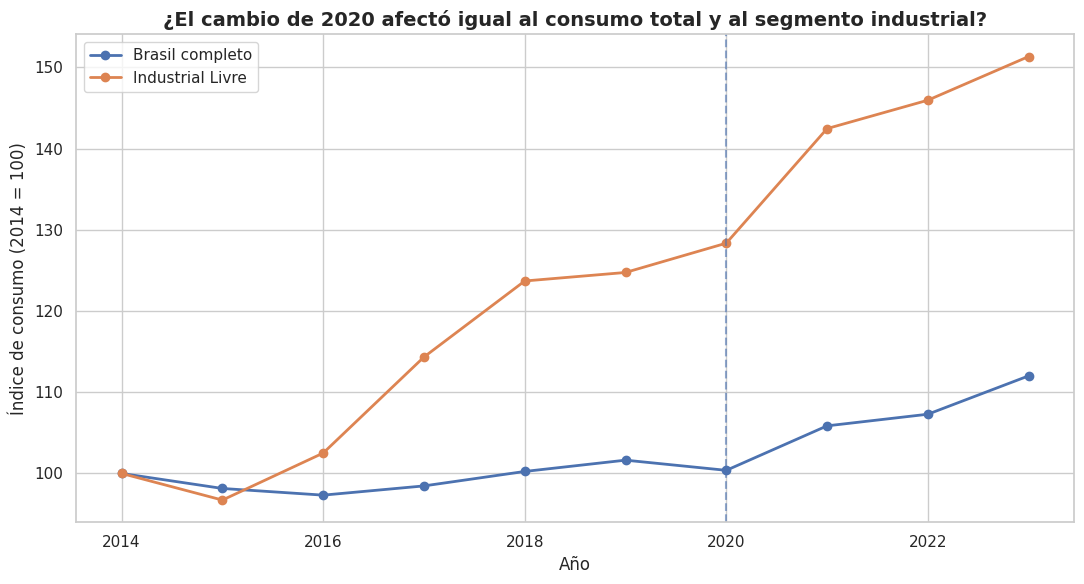

Variación porcentual anual:


,Brasil completo,Industrial Livre
ano,,
2014,NaN,NaN
2015,-1.85,-3.28
2016,-0.84,5.98
2017,1.17,11.53
2018,1.81,8.19
2019,1.39,0.85
2020,-1.23,2.89
2021,5.46,10.99
2022,1.35,2.46


In [ ]:
# Consumo anual del dataset completo.
consumo_nacional_anual = (
    df
    .groupby('ano')['Consumo']
    .sum()
)

# Consumo anual del segmento analizado para el datacenter.
consumo_objetivo_anual = (
    df_analisis
    .groupby('ano')['Consumo']
    .sum()
)

comparacion_anual = pd.DataFrame({
    'Brasil completo': consumo_nacional_anual,
    'Industrial Livre': consumo_objetivo_anual
})

# Índice base 100: permite comparar tendencias entre series de distinta escala.
indice_100 = comparacion_anual.div(
    comparacion_anual.loc[2014]
).mul(100)

plt.figure(figsize=(11, 6))

plt.plot(
    indice_100.index,
    indice_100['Brasil completo'],
    marker='o',
    linewidth=2,
    label='Brasil completo'
)
plt.plot(
    indice_100.index,
    indice_100['Industrial Livre'],
    marker='o',
    linewidth=2,
    label='Industrial Livre'
)

# Marcamos 2020 porque es el año que queremos investigar.
plt.axvline(2020, linestyle='--', alpha=0.6)

plt.title(
    '¿El cambio de 2020 afectó igual al consumo total y al segmento industrial?',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Año')
plt.ylabel('Índice de consumo (2014 = 100)')
plt.legend()
plt.tight_layout()
plt.show()

# Calculamos la variación anual para cuantificar lo observado en la línea.
variacion_anual = comparacion_anual.pct_change() * 100

print('Variación porcentual anual:')
display(variacion_anual.round(2))

### Lectura temporal

La comparación permite comprobar si el cambio observado en el consumo total también aparece en el segmento industrial del mercado libre.

El punto importante es que **un comportamiento agregado puede ocultar comportamientos diferentes entre segmentos**. El dataset muestra el patrón, pero no demuestra por sí solo su causa económica o social.

# 6. Estabilidad histórica

Para un datacenter no interesa solamente localizar estados con gran consumo. También queremos comparar cuán regular ha sido esa demanda a lo largo del tiempo.

Calculamos por estado:

- **consumo medio mensual**: representa escala histórica de demanda;
- **desviación estándar**: mide dispersión;
- **coeficiente de variación (CV)**: desviación estándar / media × 100.

Un CV menor representa menor variabilidad relativa del **consumo observado**. No mide directamente la confiabilidad de la red eléctrica.

In [ ]:
# Estadísticas mensuales por estado.
df_stats = (
    df_analisis
    .groupby('UF')['Consumo']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={
        'mean': 'Media_Consumo',
        'std': 'StdDev_Consumo'
    })
)

# Coeficiente de variación: permite comparar variabilidad relativa
# entre estados con diferentes niveles medios de consumo.
df_stats['CV_%'] = (
    df_stats['StdDev_Consumo'] /
    df_stats['Media_Consumo'] * 100
).round(2)

print('Estados con menor variabilidad relativa:')
display(
    df_stats
    .sort_values('CV_%')
    .head(10)
)

Estados con menor variabilidad relativa:


,UF,Media_Consumo,StdDev_Consumo,CV_%
14,RJ,5.996849e+05,57688.723631,9.62
6,MG,2.327362e+06,250422.821123,10.76
9,PA,9.660785e+05,105664.148901,10.94
3,ES,2.909544e+05,34332.224605,11.80
19,SE,8.177385e+04,9875.051530,12.08
20,SP,3.160979e+06,411174.316548,13.01
15,RN,7.626313e+04,10391.676022,13.63
2,DF,4.168307e+04,7028.237974,16.86
8,MT,1.251899e+05,22902.178915,18.29
10,PB,8.515420e+04,16868.135585,19.81


**Interpretación:** Los estados presentan diferentes niveles de variabilidad histórica. Un CV menor representa un comportamiento relativamente más estable respecto a su consumo medio.

**Conclusión:** El coeficiente de variación nos permite agregar una segunda dimensión al análisis: ya no buscamos solamente estados con gran consumo, sino estados que combinen **escala y estabilidad**.

# 7. Matriz de decisión: escala vs estabilidad

Este es el gráfico principal de la preselección para el datacenter.

- **Eje X:** consumo medio mensual. Más a la derecha = mayor escala histórica de demanda.
- **Eje Y:** coeficiente de variación. Más abajo = menor variabilidad histórica.

Las medianas dividen el gráfico en cuatro zonas. Para la preselección nos interesa principalmente el grupo con **consumo igual o superior a la mediana y CV igual o inferior a la mediana**.

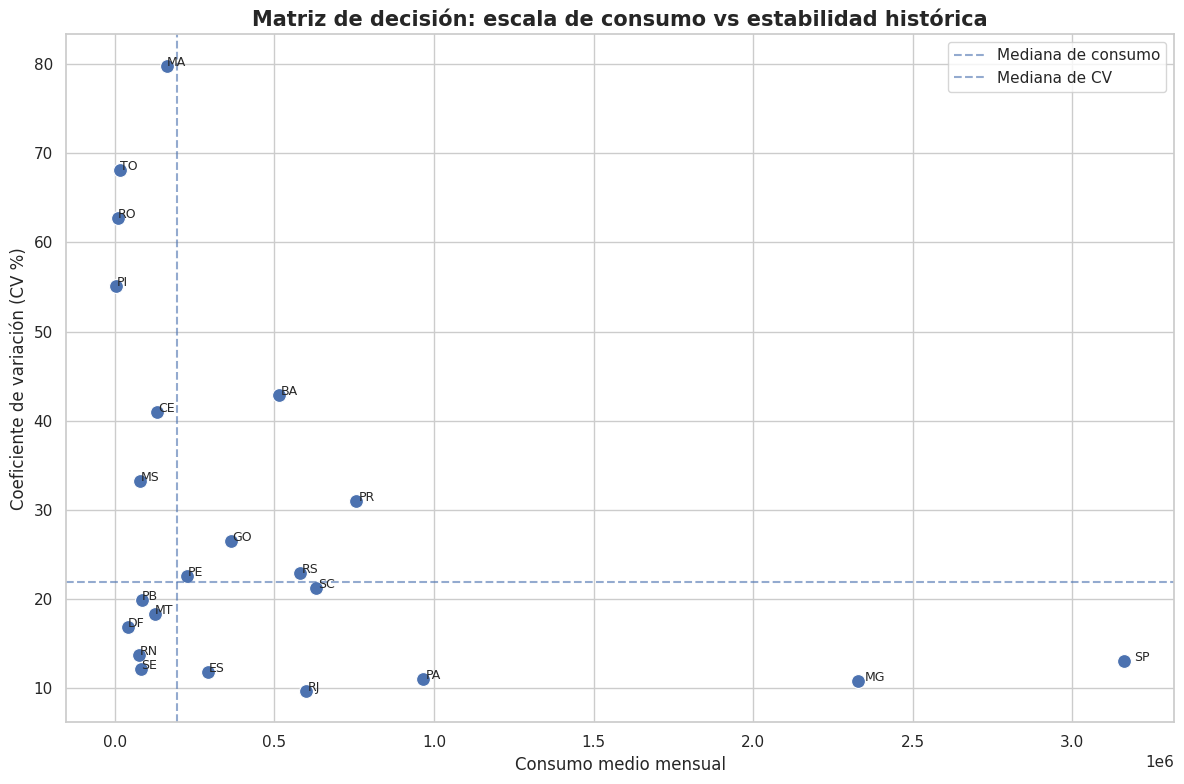

In [ ]:
# Medianas que utilizaremos como referencias de la matriz.
mediana_volumen = df_stats['Media_Consumo'].median()
mediana_cv = df_stats['CV_%'].median()

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_stats,
    x='Media_Consumo',
    y='CV_%',
    s=100
)

# Etiquetamos cada punto con la sigla del estado.
for _, fila in df_stats.iterrows():
    plt.text(
        fila['Media_Consumo'] * 1.01,
        fila['CV_%'],
        fila['UF'],
        fontsize=9
    )

# Líneas de referencia para formar los cuatro cuadrantes.
plt.axvline(
    mediana_volumen,
    linestyle='--',
    alpha=0.6,
    label='Mediana de consumo'
)
plt.axhline(
    mediana_cv,
    linestyle='--',
    alpha=0.6,
    label='Mediana de CV'
)

plt.title(
    'Matriz de decisión: escala de consumo vs estabilidad histórica',
    fontsize=15,
    fontweight='bold'
)
plt.xlabel('Consumo medio mensual')
plt.ylabel('Coeficiente de variación (CV %)')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación:** Los estados ubicados en la zona de mayor consumo medio y menor coeficiente de variación presentan la combinación más favorable según los criterios definidos en este análisis.

A partir de esta matriz, los estados que destacan como candidatos preliminares son:

- **São Paulo (SP)**
- **Minas Gerais (MG)**
- **Pará (PA)**
- **Santa Catarina (SC)**
- **Rio de Janeiro (RJ)**

**Conclusión:** Estos estados presentan el mayor interés para avanzar a una segunda etapa de evaluación de un posible datacenter, ya que combinan una escala energética relevante con una estabilidad histórica relativamente favorable.

Esto representa una **preselección energética**, no una decisión definitiva de ubicación.

## 8. Candidatos preliminares

La selección utiliza una regla simple y reproducible:

1. consumo medio mensual igual o superior a la mediana;
2. CV igual o inferior a la mediana;
3. dentro de ese grupo, mostramos los cinco estados con mayor consumo medio.

Esta regla no declara cuál es el mejor lugar para un datacenter. Solo reduce el conjunto de estados que merecen una evaluación posterior.

In [ ]:
# Estados que cumplen simultáneamente los criterios de escala y estabilidad.
candidatos = df_stats[
    (df_stats['Media_Consumo'] >= mediana_volumen) &
    (df_stats['CV_%'] <= mediana_cv)
].copy()

# Cinco estados con mayor consumo medio dentro del grupo elegible.
finalistas = (
    candidatos
    .nlargest(5, 'Media_Consumo')
    [['UF', 'Media_Consumo', 'CV_%']]
    .reset_index(drop=True)
)

print('Candidatos preliminares para continuar el estudio:')
display(finalistas)

Candidatos preliminares para continuar el estudio:


,UF,Media_Consumo,CV_%
0,SP,3.160979e+06,13.01
1,MG,2.327362e+06,10.76
2,PA,9.660785e+05,10.94
3,SC,6.313338e+05,21.19
4,RJ,5.996849e+05,9.62


# 9. Conclusiones y limitaciones

El análisis permitió pasar de un conjunto de datos nacional a una preselección de estados con características energéticas relevantes para continuar evaluando la instalación de un centro de datos.

El criterio principal combinó dos aspectos:

- **escala de consumo industrial**, representada por el consumo medio mensual;
- **estabilidad histórica**, medida mediante el coeficiente de variación (CV).

Los estados que mejor cumplieron simultáneamente estos criterios fueron:

- **São Paulo (SP)**
- **Minas Gerais (MG)**
- **Pará (PA)**
- **Santa Catarina (SC)**
- **Rio de Janeiro (RJ)**

Estos estados presentan una combinación favorable dentro del dataset entre una demanda industrial históricamente elevada y una variabilidad relativamente menor.

Por esta razón, son los estados con **mayor interés para continuar la evaluación de un posible datacenter** a partir de la información energética analizada.

Entre ellos, los estados con mayor consumo medio dentro del grupo seleccionado merecen especial atención, ya que muestran una mayor presencia histórica de grandes cargas industriales.

Sin embargo, esta selección debe interpretarse como una **preselección energética**, no como una decisión definitiva de ubicación.

El dataset utilizado no contiene información sobre:

- precio real de la electricidad;
- capacidad disponible de la red;
- calidad e interrupciones del suministro;
- infraestructura de fibra óptica;
- temperatura y necesidades de refrigeración;
- disponibilidad de agua y terreno;
- impuestos e incentivos.

Por lo tanto, el siguiente paso sería comparar estos cinco estados utilizando esas variables externas.

> **Conclusión final:** según los patrones de consumo y estabilidad histórica observados, **SP, MG, PA, SC y RJ son los estados que presentan mayor potencial para avanzar a una segunda etapa de evaluación para la instalación de un datacenter**.